# 💳 Credit Card Fraud Detection Using Machine Learning: An End-to-End Classification Pipeline

## 📌 Project Overview

Credit card fraud is one of the most significant challenges faced by financial institutions. Fraudulent transactions result in billions of dollars in losses annually and can severely impact customer trust. Detecting fraud is challenging because fraudulent transactions represent only a very small percentage of all transactions, making this a highly imbalanced classification problem.

In this project, we build an end-to-end machine learning pipeline to detect fraudulent credit card transactions. The notebook covers exploratory data analysis (EDA), data preprocessing, model training, evaluation, and business recommendations.

---

## 🎯 Objectives

- Understand the structure of the dataset
- Perform exploratory data analysis
- Investigate class imbalance
- Preprocess the data
- Train multiple machine learning models
- Evaluate model performance using appropriate metrics
- Draw actionable business insights

---

## 🛠 Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

## 📊 Dataset

This dataset contains anonymized credit card transactions made by European cardholders.

- Total Transactions: **284,807**
- Fraudulent Transactions: **492**
- Genuine Transactions: **284,315**

Because fraudulent transactions account for less than 0.2% of the data, accuracy alone is not a reliable evaluation metric. Instead, we focus on Precision, Recall, F1-score, and ROC-AUC.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [5]:
pd.set_option("display.max_columns", None)

In [6]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [7]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 📂 Data Understanding

Before building any machine learning model, it is important to understand the structure and quality of the dataset. In this section, we inspect the dataset, identify missing values, examine data types, and understand the distribution of the target variable.

In [8]:
# Shape of the dataset

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 284807
Columns: 31


In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()
df.describe().T



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [11]:
missing = df.isnull().sum()
missing[missing>0]

Series([], dtype: int64)

### Observation

- The dataset contains **284,807 transactions**.
- There are **31 columns**.
- No missing values are present.
- Most features are numerical and anonymized (V1–V28).
- The target variable is **Class**, where:
  - **0 → Genuine Transaction**
  - **1 → Fraudulent Transaction**

# 🎯 Class Distribution

Understanding the distribution of fraudulent and genuine transactions is critical because fraud detection is an imbalanced classification problem.

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_percent)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


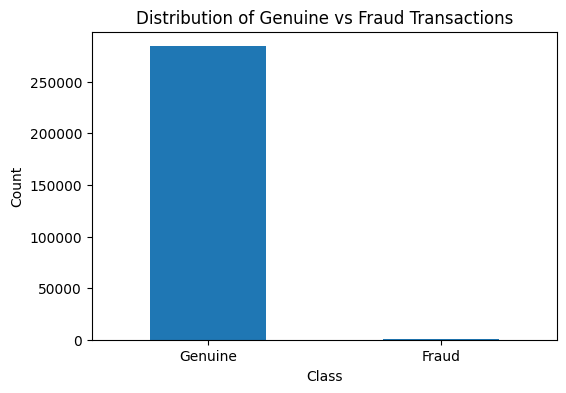

In [14]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Distribution of Genuine vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Genuine","Fraud"], rotation=0)

plt.show()

### Key Insight

The dataset is **extremely imbalanced**, with fraudulent transactions accounting for only **0.17%** of all observations.

This means that **accuracy alone is not an appropriate evaluation metric**. Instead, metrics such as Precision, Recall, F1-score, and ROC-AUC will be used to evaluate model performance.


# 💰 Transaction Amount Analysis

Analyzing transaction amounts helps us understand spending behavior and identify whether fraudulent transactions tend to involve unusually large or small amounts.

In [15]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

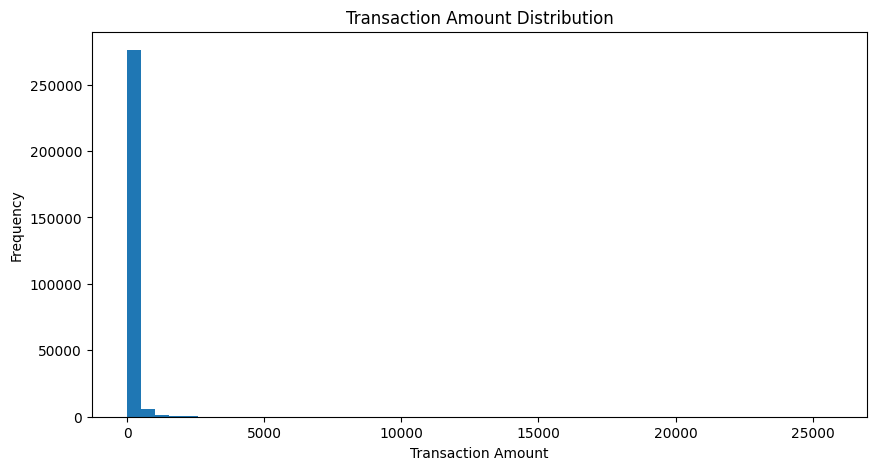

In [16]:
plt.figure(figsize=(10,5))

plt.hist(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

# ⚙️ Data Preprocessing

Machine learning models require clean and well-prepared data. In this section, we prepare the dataset by separating features and the target variable, splitting the data into training and testing sets, and scaling the transaction amount feature.


In [17]:
# Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (227845, 30)
Testing Samples: (56962, 30)


### Why Stratified Splitting?

Since fraudulent transactions make up less than 0.2% of the dataset, stratified sampling ensures that both the training and testing datasets maintain the same class distribution. This leads to a more reliable evaluation.


In [19]:
scaler = StandardScaler()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])

X_test["Amount"] = scaler.transform(X_test[["Amount"]])

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,-0.113729,0.510277,0.061258,-0.066555,1.328702,0.352514,-0.765670,0.141938,-0.451365,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494
180305,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,-0.254903,0.325560,-0.405327,0.721068,-0.148445,-0.754029,-0.270842,-0.695698,-0.274411,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764
42664,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,-0.386845,1.820161,0.747777,0.122746,-1.723285,1.123344,-0.724616,0.147255,0.004631,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693
198723,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,0.093136,-0.722450,-0.468757,-0.195288,-0.638683,-0.065888,0.072781,0.768237,0.257424,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360
82325,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,-0.251076,-0.054708,-0.782698,0.134659,-0.483007,-2.096099,-0.399525,1.597589,-0.082746,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281


# 🤖 Model 1: Logistic Regression

Logistic Regression is a simple yet effective baseline classification algorithm. It provides a good benchmark for evaluating more complex models.


In [20]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [21]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [22]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_log))

Accuracy : 0.9991924440855307
Precision: 0.825
Recall   : 0.673469387755102
F1 Score : 0.7415730337078652
ROC AUC  : 0.9501384614059467


In [23]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.67      0.74        98

    accuracy                           1.00     56962
   macro avg       0.91      0.84      0.87     56962
weighted avg       1.00      1.00      1.00     56962



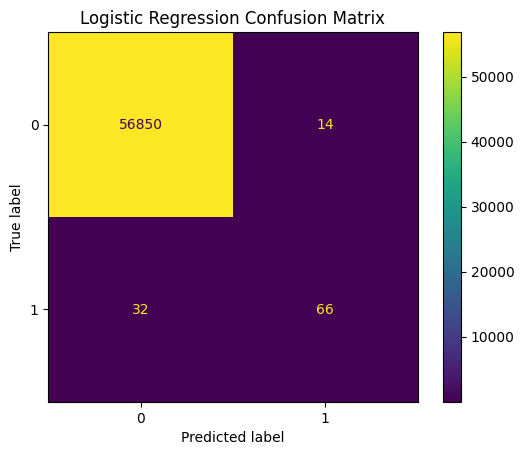

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

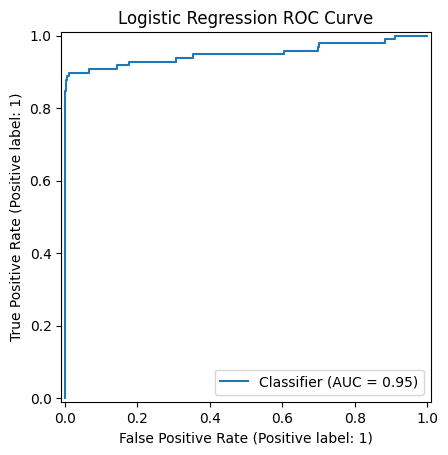

In [25]:
RocCurveDisplay.from_predictions(y_test, y_prob_log)

plt.title("Logistic Regression ROC Curve")

plt.show()

### Observation

Logistic Regression provides a strong baseline model. However, because the dataset is highly imbalanced, accuracy alone is not sufficient. Recall and Precision are more meaningful metrics when evaluating fraud detection systems.

# 🌲 Model 2: Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is commonly used for fraud detection because it can capture complex relationships in the data.


In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [28]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104
ROC AUC  : 0.9630272515590367


In [29]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



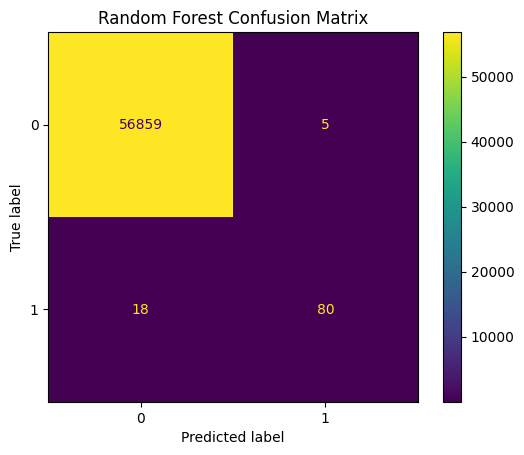

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()

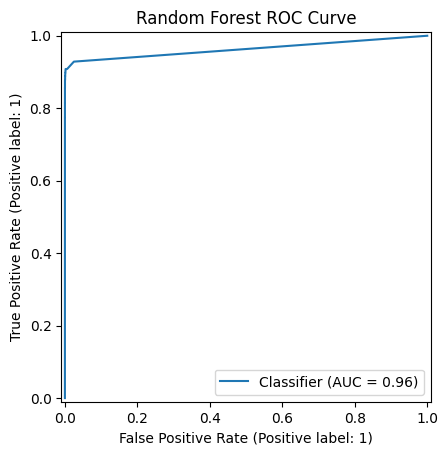

In [31]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest ROC Curve")

plt.show()

# ⭐ Feature Importance

One advantage of Random Forest is that it provides feature importance scores, helping us understand which variables contribute the most to fraud detection.


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


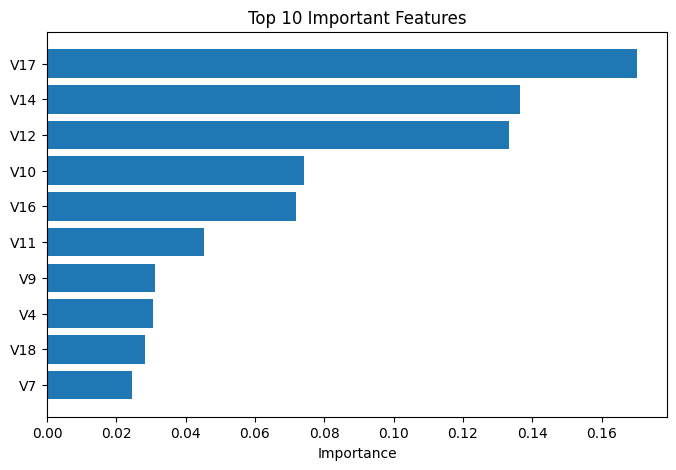

In [33]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [34]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1 Score","ROC AUC"],
    "Logistic Regression": [
        accuracy_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_log),
        roc_auc_score(y_test,y_prob_log)
    ],
    "Random Forest": [
        accuracy_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_rf),
        roc_auc_score(y_test,y_prob_rf)
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.999192,0.999596
1,Precision,0.825000,0.941176
2,Recall,0.673469,0.816327
3,F1 Score,0.741573,0.874317
4,ROC AUC,0.950138,0.963027


# 💼 Business Recommendations

Based on the model evaluation, the following recommendations are proposed:

- Deploy the Random Forest model as the primary fraud detection model.
- Flag high-risk transactions for manual review before payment approval.
- Continuously retrain the model using newly collected transaction data.
- Monitor precision and recall to ensure consistent fraud detection performance.
- Integrate customer behavior, location, and device information to further improve detection accuracy.

# 🚀 Future Improvements

This project can be enhanced by:

- Applying SMOTE or other oversampling techniques to address class imbalance.
- Experimenting with advanced models such as XGBoost or LightGBM.
- Performing hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Optimizing the classification threshold to improve recall.
- Deploying the model using Flask or FastAPI for real-time fraud detection.

# ✅ Conclusion

This project presented an end-to-end machine learning pipeline for detecting fraudulent credit card transactions.

After evaluating Logistic Regression and Random Forest classifiers, the Random Forest model demonstrated superior performance across Precision, Recall, F1-score, and ROC-AUC metrics.

The results highlight the importance of using evaluation metrics beyond accuracy when working with highly imbalanced datasets. The developed workflow demonstrates practical skills in data preprocessing, exploratory data analysis, model training, evaluation, and business interpretation.

# 📌 Executive Summary

- Dataset Size: **284,807** transactions
- Fraud Cases: **492**
- Models Evaluated:
  - Logistic Regression
  - Random Forest
- Best Model: **Random Forest**
- Best ROC-AUC: **96.30%**
- Best F1-Score: **87.43%**

The Random Forest model provided the best overall balance between identifying fraudulent transactions and minimizing false alarms, making it a strong candidate for deployment in real-world fraud detection systems.

## 👩‍💻 About the Author

Hi, I'm Sejal Rane.

I'm a Computer Science student passionate about Artificial Intelligence, Machine Learning, and Data Science.

I'm currently building real-world AI projects while preparing for AI/ML internship opportunities.

If you found this notebook useful, feel free to upvote it and connect with me on LinkedIn.

#  Key Learnings

During this project I learned:

- Handling highly imbalanced datasets
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Logistic Regression
- Random Forest
- Model evaluation
- Precision vs Recall
- ROC-AUC
- Business interpretation of ML models